In [1]:
!git clone https://github.com/devangelista2/IPPy.git

Cloning into 'IPPy'...
remote: Enumerating objects: 380, done.
remote: Counting objects: 100% (380/380), done.
remote: Compressing objects: 100% (270/270), done.
remote: Total 380 (delta 182), reused 285 (delta 90), pack-reused 0 (from 0)
Receiving objects: 100% (380/380), 7.24 MiB | 12.03 MiB/s, done.
Resolving deltas: 100% (182/182), done.


In [2]:
!pip install numpy torch torchvision numba astra-toolbox scikit-image Pillow matplotlib cupy-cuda12x tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 40.8 MB/s eta 0:00:00


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import sys
import os
import time

import glob
import math
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from PIL import Image
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from tqdm.auto import tqdm

# In Colab, we replace the __file__ logic with the actual path to the cloned repository
repo_path = os.path.abspath('/content/IPPy')
if repo_path not in sys.path:
    sys.path.append(repo_path)

from IPPy import operators, utilities


book_root = Path('.').resolve()
weights_dir = book_root / 'weights'
weights_dir.mkdir(exist_ok=True)
dataset_dir = book_root / "drive" / "MyDrive" / "Mayo"

Device: cuda
Training images: 3306
Test images: 327
Weights directory: /content/weights


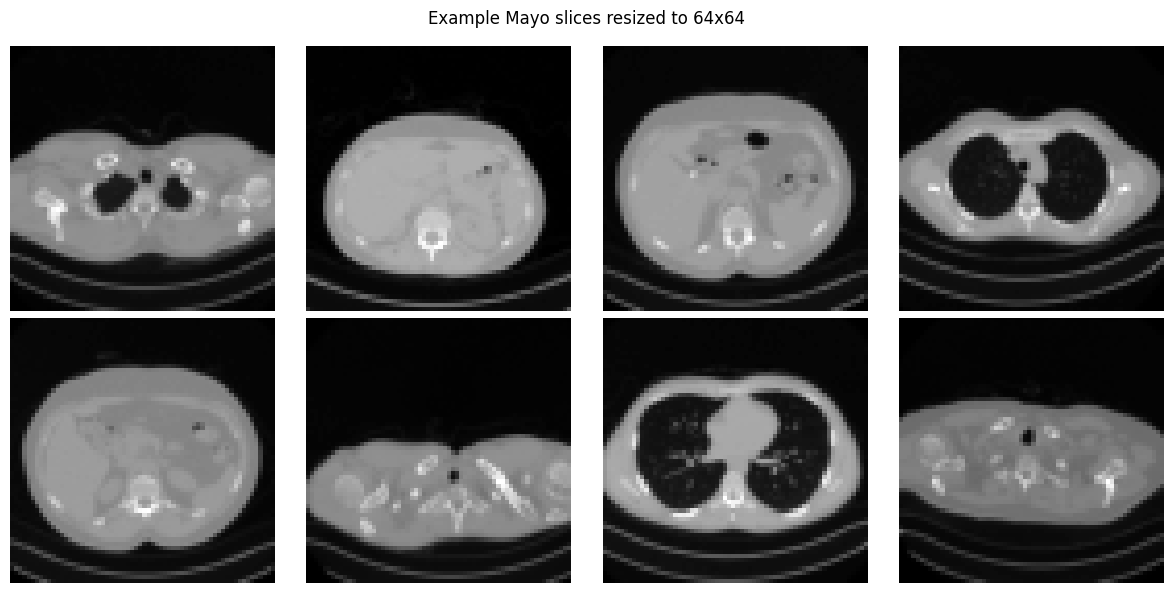

In [5]:
class MayoDataset(Dataset):
    def __init__(self, data_path, data_shape=64):
        super().__init__()
        self.fname_list = sorted(glob.glob(f'{data_path}/*/*.png'))
        self.transform = transforms.Compose([
            transforms.Resize((data_shape, data_shape), antialias=True),
            transforms.ToTensor(),
        ])

    def __len__(self):
        return len(self.fname_list)

    def __getitem__(self, idx):
        x = Image.open(self.fname_list[idx]).convert('L')
        return self.transform(x)


def show_batch(batch, title, ncols=4):
    batch = batch.detach().cpu()
    n = min(len(batch), 8)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(3 * ncols, 3 * nrows))
    axes = axes.reshape(-1) if hasattr(axes, 'reshape') else [axes]
    for ax, image in zip(axes, batch[:n]):
        ax.imshow(image.squeeze(), cmap='gray')
        ax.axis('off')
    for ax in axes[n:]:
        ax.axis('off')
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


device = utilities.get_device()
train_dataset = MayoDataset(data_path=str(dataset_dir / 'train'), data_shape=64)
test_dataset = MayoDataset(data_path=str(dataset_dir  / 'test'), data_shape=64)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print('Device:', device)
print('Training images:', len(train_dataset))
print('Test images:', len(test_dataset))
print('Weights directory:', weights_dir)

x_batch = next(iter(train_loader))
show_batch(x_batch[:8], 'Example Mayo slices resized to 64x64')

In [6]:
# Define a helper function to create a normalization layer given the number of channels
def norm_layer(channels):
    # Set the number of groups to 8 if there are at least 8 channels; otherwise, set it to 1 (which makes it act like Layer Normalization)
    num_groups = 8 if channels >= 8 else 1
    # Initialize and return a PyTorch GroupNorm module with the calculated number of groups and the specified number of channels
    return nn.GroupNorm(num_groups=num_groups, num_channels=channels)


# Define a Residual Block class that inherits from PyTorch's base neural network module
class ResidualBlock(nn.Module):
    # Constructor method that takes the number of input/output channels as an argument
    def __init__(self, channels):
        # Call the parent class (nn.Module) constructor to properly initialize the module
        super().__init__()
        # Group the sequence of layers that make up the residual branch into an nn.Sequential container
        self.block = nn.Sequential(
            # First, apply the custom normalization layer to the input
            norm_layer(channels),
            # Apply the SiLU (Swish) non-linear activation function
            nn.SiLU(),
            # Apply a 2D convolution that maintains the spatial dimensions (padding=1) and channel count
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            # Apply a second normalization layer
            norm_layer(channels),
            # Apply a second SiLU activation function
            nn.SiLU(),
            # Apply a second 2D convolution to finalize the feature transformation for this block
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
        )

    # Define the forward pass logic for the ResidualBlock
    def forward(self, x):
        # Add the original input (x) to the output of the sequential block to create the residual/skip connection
        return x + self.block(x)


# Define a Downsampling Block class used in the encoder to reduce spatial dimensions
class DownBlock(nn.Module):
    # Constructor taking the number of input channels and the desired number of output channels
    def __init__(self, in_ch, out_ch):
        # Call the parent nn.Module constructor
        super().__init__()
        # Group the downsampling sequence into an nn.Sequential container
        self.block = nn.Sequential(
            # Use a convolution with stride=2 to halve the height and width of the feature map while changing the channel count
            nn.Conv2d(in_ch, out_ch, kernel_size=4, stride=2, padding=1),
            # Normalize the newly created features
            norm_layer(out_ch),
            # Apply the SiLU activation function
            nn.SiLU(),
            # Pass the features through a ResidualBlock to learn deeper representations at this resolution
            ResidualBlock(out_ch),
        )

    # Define the forward pass logic for the DownBlock
    def forward(self, x):
        # Pass the input tensor through the sequential block and return the downsampled result
        return self.block(x)


# Define an Upsampling Block class used in the decoder to increase spatial dimensions
class UpsampleBlock(nn.Module):
    # Constructor taking the number of input channels and the desired number of output channels
    def __init__(self, in_ch, out_ch):
        # Call the parent nn.Module constructor
        super().__init__()
        # Group the upsampling sequence into an nn.Sequential container
        self.block = nn.Sequential(
            # Double the height and width of the feature map using bilinear interpolation without corner alignment
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            # Apply a convolution to refine the upsampled features and change the channel dimension
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            # Normalize the refined features
            norm_layer(out_ch),
            # Apply the SiLU activation function
            nn.SiLU(),
            # Pass the features through a ResidualBlock to learn deeper representations at this new resolution
            ResidualBlock(out_ch),
        )

    # Define the forward pass logic for the UpsampleBlock
    def forward(self, x):
        # Pass the input tensor through the sequential block and return the upsampled result
        return self.block(x)


# Define the main Convolutional Variational Autoencoder class
class ConvVAE(nn.Module):
    # Constructor taking the size of the latent bottleneck space (default is 64)
    def __init__(self, latent_dim=64):
        # Call the parent nn.Module constructor
        super().__init__()
        # Store the dimension of the latent space as an instance variable
        self.latent_dim = latent_dim

        # Define the initial "stem" of the encoder to process the raw input image
        self.stem = nn.Sequential(
            # Convert a 1-channel (grayscale) input image into a 32-channel feature map, keeping original spatial size
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            # Normalize the 32-channel features
            norm_layer(32),
            # Apply the SiLU activation function
            nn.SiLU(),
            # Pass through an initial ResidualBlock to extract basic visual features
            ResidualBlock(32),
        )
        # First downsampling block: halves spatial size, increases channels from 32 to 64
        self.down1 = DownBlock(32, 64)
        # Second downsampling block: halves spatial size, increases channels from 64 to 128
        self.down2 = DownBlock(64, 128)
        # Third downsampling block: halves spatial size, increases channels from 128 to 256
        self.down3 = DownBlock(128, 256)
        # Fourth downsampling block: halves spatial size, increases channels from 256 to 512
        self.down4 = DownBlock(256, 512)

        # Fully connected layer to map the flattened spatial features to the mean (mu) of the latent distribution
        self.fc_mu = nn.Linear(512 * 4 * 4, latent_dim)
        # Fully connected layer to map the flattened spatial features to the log-variance (logvar) of the latent distribution
        self.fc_logvar = nn.Linear(512 * 4 * 4, latent_dim)
        # Fully connected layer to map the sampled latent vector (z) back to the flattened spatial feature dimension
        self.fc_decode = nn.Linear(latent_dim, 512 * 4 * 4)

        # First upsampling block: doubles spatial size, decreases channels from 512 to 256
        self.up1 = UpsampleBlock(512, 256)
        # Second upsampling block: doubles spatial size, decreases channels from 256 to 128
        self.up2 = UpsampleBlock(256, 128)
        # Third upsampling block: doubles spatial size, decreases channels from 128 to 64
        self.up3 = UpsampleBlock(128, 64)
        # Fourth upsampling block: doubles spatial size, decreases channels from 64 to 32
        self.up4 = UpsampleBlock(64, 32)

        # Final layers to process the upsampled features back into an image format
        self.out_conv = nn.Sequential(
            # Normalize the 32-channel features
            norm_layer(32),
            # Apply the SiLU activation function
            nn.SiLU(),
            # Apply a final convolution to collapse the 32 channels down to 1 channel (reconstructed image)
            nn.Conv2d(32, 1, kernel_size=3, padding=1),
            # Apply a Sigmoid activation to squash the output pixel values into the [0, 1] range
            nn.Sigmoid(),
        )

    # Define the encoding pass to get the latent distribution parameters
    def encode(self, x):
        # Pass the input image through the initial stem layers
        h = self.stem(x)
        # Pass through the first downsampling block
        h = self.down1(h)
        # Pass through the second downsampling block
        h = self.down2(h)
        # Pass through the third downsampling block
        h = self.down3(h)
        # Pass through the fourth downsampling block (output is shape [Batch, 512, 4, 4] assuming 64x64 input)
        h = self.down4(h)
        # Flatten the 4D tensor into a 2D matrix (Batch size x flattened features) starting from the channel dimension
        h = h.flatten(start_dim=1)
        # Calculate the latent mean vector (mu)
        mu = self.fc_mu(h)
        # Calculate the log-variance vector, clamping the values to prevent numerical instability (exploding/vanishing variance)
        logvar = self.fc_logvar(h).clamp(min=-4.5, max=1.0)
        # Return both the mean and the log-variance
        return mu, logvar

    # Define the reparameterization trick to allow gradients to flow through the stochastic sampling process
    def reparameterize(self, mu, logvar):
        # Calculate standard deviation by halving the log-variance and exponentiating it: std = exp(0.5 * logvar)
        std = torch.exp(0.5 * logvar)
        # Sample random noise (epsilon) from a standard normal distribution matching the shape of the standard deviation tensor
        eps = torch.randn_like(std)
        # Scale the noise by the standard deviation and add the mean to get the sampled latent vector (z)
        return mu + eps * std

    # Define the decoding pass to reconstruct the image from the latent vector
    def decode(self, z):
        # Map the latent vector to the spatial dimension shape and reshape it back into a 4D tensor [Batch, 512, 4, 4]
        h = self.fc_decode(z).view(z.shape[0], 512, 4, 4)
        # Pass through the first upsampling block
        h = self.up1(h)
        # Pass through the second upsampling block
        h = self.up2(h)
        # Pass through the third upsampling block
        h = self.up3(h)
        # Pass through the fourth upsampling block
        h = self.up4(h)
        # Pass through the final convolutions to generate the reconstructed image and return it
        return self.out_conv(h)

    # Define a helper method for generation that skips the random sampling noise
    def reconstruct_deterministic(self, x):
        # Encode the input image to get the mean (mu), ignoring the log-variance
        mu, _ = self.encode(x)
        # Directly decode the mean (mu) instead of sampling, yielding a deterministic reconstruction
        return self.decode(mu)

    # Define the full forward pass for training the VAE
    def forward(self, x):
        # Encode the input to get the mean and log-variance
        mu, logvar = self.encode(x)
        # Sample the latent vector (z) using the reparameterization trick
        z = self.reparameterize(mu, logvar)
        # Decode the sampled latent vector into the reconstructed image (x_hat)
        x_hat = self.decode(z)
        # Return the reconstructed image, mean, and log-variance (all needed for the loss function)
        return x_hat, mu, logvar


# Define the loss function for the VAE (Reconstruction Loss + KL Divergence)
def vae_loss(x_hat, x, mu, logvar, gamma=5e-4, capacity=0.0):
    # Calculate the L1 (Mean Absolute Error) reconstruction loss between the generated image and original image
    recon_l1 = F.l1_loss(x_hat, x)
    # Calculate the Mean Squared Error (L2) reconstruction loss
    recon_mse = F.mse_loss(x_hat, x)
    # Combine the L1 loss and a scaled down MSE loss to create a robust blended reconstruction loss
    recon = recon_l1 + 0.1 * recon_mse
    # Calculate the Kullback-Leibler (KL) divergence per sample analytically using mu and logvar
    kl_per_sample = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)
    # Average the KL divergence across the batch size
    kl = kl_per_sample.mean()
    # Calculate the total loss: reconstruction loss + weighted absolute difference between KL and a target capacity (InfoVAE/beta-VAE variant)
    loss = recon + gamma * torch.abs(kl - capacity)
    # Return the total combined loss, the isolated reconstruction loss, and the isolated KL loss (useful for logging)
    return loss, recon, kl

AE pretrain 1/10:   0%|          | 0/104 [00:00<?, ?it/s]

AE pretrain 2/10:   0%|          | 0/104 [00:00<?, ?it/s]

AE pretrain 3/10:   0%|          | 0/104 [00:00<?, ?it/s]

AE pretrain 4/10:   0%|          | 0/104 [00:00<?, ?it/s]

AE pretrain 5/10:   0%|          | 0/104 [00:00<?, ?it/s]

...

VAE finetune 37/40:   0%|          | 0/104 [00:00<?, ?it/s]

VAE finetune 38/40:   0%|          | 0/104 [00:00<?, ?it/s]

VAE finetune 39/40:   0%|          | 0/104 [00:00<?, ?it/s]

VAE finetune 40/40:   0%|          | 0/104 [00:00<?, ?it/s]

Saved VAE weights to: /content/weights/VAE.pth
Posterior mean std: 0.416
Posterior std mean: 0.929


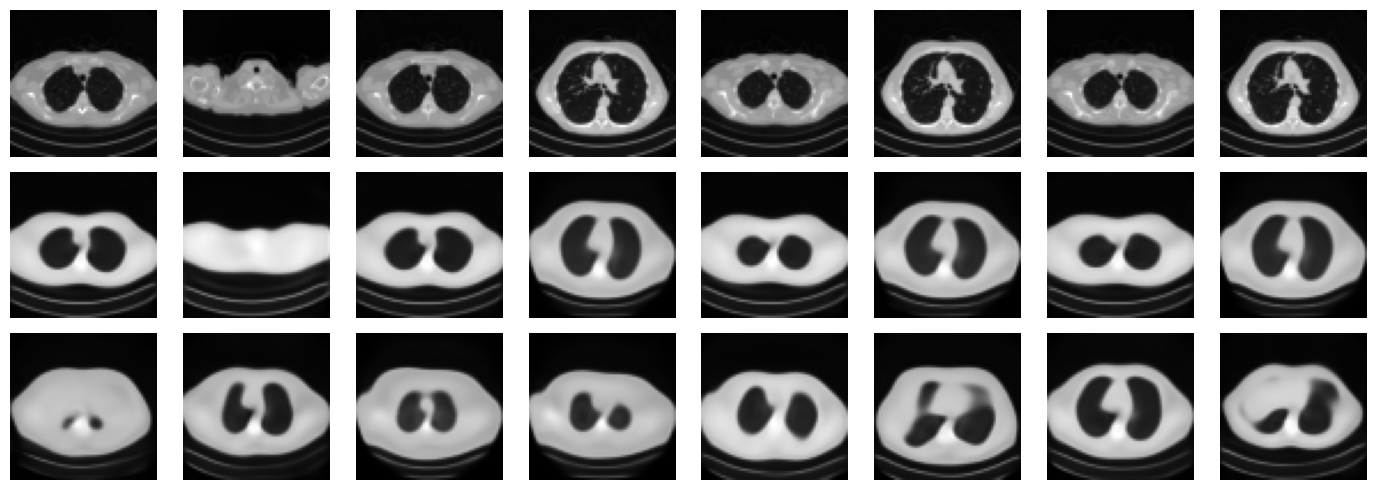

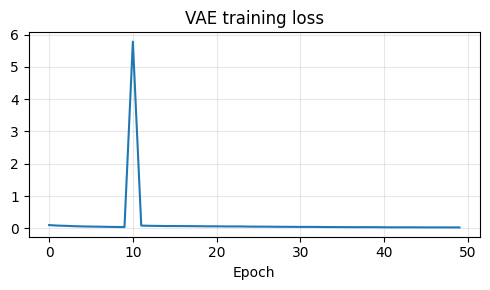

In [7]:
# Set the random seed for PyTorch to ensure reproducibility of weight initialization and stochastic operations
torch.manual_seed(0)

# Define the size of the latent representation vector
latent_dim = 64
# Instantiate the ConvVAE model with the specified latent dimension and move it to the compute device (e.g., GPU or CPU)
vae = ConvVAE(latent_dim=latent_dim).to(device)
# Initialize the Adam optimizer for the first training stage (pretraining) with a learning rate of 0.001
pretrain_optimizer = torch.optim.Adam(vae.parameters(), lr=1e-3)
# Initialize a separate Adam optimizer for the second stage (fine-tuning) with a lower learning rate of 0.0003
finetune_optimizer = torch.optim.Adam(vae.parameters(), lr=3e-4)
# Set the number of epochs for the deterministic Autoencoder pretraining stage to 10
pretrain_epochs = 10
# Set the number of epochs for the Variational Autoencoder fine-tuning stage to 40
finetune_epochs = 40
# Initialize an empty list to track and store the average loss per epoch for plotting later
vae_history = []
# Define the file path where the trained model weights will be saved
vae_path = weights_dir / 'VAE.pth'

# Stage 1: deterministic AutoEncoder pretraining (helps the model learn basic features before introducing randomness)
# Loop over the specified number of pretraining epochs
for epoch in range(pretrain_epochs):
    # Set the model to training mode (enabling tracking of gradients and specific layer behaviors if applicable)
    vae.train()
    # Initialize a variable to accumulate the total loss for the current epoch
    epoch_loss = 0.0
    # Wrap the training dataloader in a tqdm progress bar with a descriptive label for the current epoch
    progress_bar = tqdm(train_loader, desc=f'AE pretrain {epoch + 1}/{pretrain_epochs}', leave=True)

    # Iterate over the batches of data provided by the dataloader
    for step, x_batch in enumerate(progress_bar, start=1):
        # Move the current batch of images to the compute device
        x_batch = x_batch.to(device)
        # Pass the batch through the model deterministically (skipping the random sampling step) to get reconstructions
        x_rec = vae.reconstruct_deterministic(x_batch)
        # Calculate the pure reconstruction loss combining L1 (Mean Absolute Error) and scaled L2 (Mean Squared Error)
        loss = F.l1_loss(x_rec, x_batch) + 0.1 * F.mse_loss(x_rec, x_batch)

        # Clear any accumulated gradients in the pretraining optimizer from previous steps
        pretrain_optimizer.zero_grad()
        # Perform backpropagation to compute the gradient of the loss with respect to the model parameters
        loss.backward()
        # Update the model parameters using the computed gradients
        pretrain_optimizer.step()

        # Add the current batch's loss value to the running total for the epoch
        epoch_loss += loss.item()
        # Update the progress bar to display the current batch loss and the running average loss
        progress_bar.set_postfix(loss=f'{loss.item():.5f}', avg=f'{epoch_loss / step:.5f}')

    # After the epoch completes, calculate the average loss and append it to the history list
    vae_history.append(epoch_loss / len(train_loader))

# Stage 2: variational fine-tuning with latent-capacity control (introduces KL divergence to shape the latent space)
# Loop over the specified number of fine-tuning epochs
for epoch in range(finetune_epochs):
    # Ensure the model is still in training mode
    vae.train()
    # Initialize a variable to accumulate the total loss for the current epoch
    epoch_loss = 0.0
    # Calculate the target KL capacity, linearly increasing it from 0 up to a maximum of 12.0 over the course of the epochs
    capacity = min(12.0, (epoch + 1) / finetune_epochs * 12.0)
    # Wrap the training dataloader in a tqdm progress bar with a descriptive label for the current stage
    progress_bar = tqdm(train_loader, desc=f'VAE finetune {epoch + 1}/{finetune_epochs}', leave=True)

    # Iterate over the batches of data
    for step, x_batch in enumerate(progress_bar, start=1):
        # Move the current batch of images to the compute device
        x_batch = x_batch.to(device)
        # Pass the batch through the full VAE forward pass, obtaining reconstructions, means, and log-variances
        x_rec, mu, logvar = vae(x_batch)
        # Compute the combined loss (reconstruction + constrained KL divergence) using the current capacity threshold
        loss, recon, kl = vae_loss(x_rec, x_batch, mu, logvar, gamma=5e-4, capacity=capacity)

        # Clear any accumulated gradients in the fine-tuning optimizer
        finetune_optimizer.zero_grad()
        # Perform backpropagation for the combined VAE loss
        loss.backward()
        # Update the model parameters using the fine-tuning optimizer
        finetune_optimizer.step()

        # Add the current batch's total loss value to the running total for the epoch
        epoch_loss += loss.item()
        # Update the progress bar to display the total loss, isolated reconstruction loss, isolated KL loss, and current capacity
        progress_bar.set_postfix(loss=f'{loss.item():.5f}', recon=f'{recon.item():.5f}', kl=f'{kl.item():.3f}', cap=f'{capacity:.2f}')

    # Append the average loss for this fine-tuning epoch to the overall history list
    vae_history.append(epoch_loss / len(train_loader))

# Extract the learned parameters (state dictionary) from the model and save them to the specified file path
torch.save(vae.state_dict(), vae_path)
# Print a confirmation message indicating where the weights were saved
print(f'Saved VAE weights to: {vae_path}')

# Instantiate a fresh, untrained ConvVAE model with the same latent dimension to test the loading process
reloaded_vae = ConvVAE(latent_dim=latent_dim)
# Load the saved parameters from disk into the new model instance safely (weights_only=True prevents code execution attacks)
reloaded_vae.load_state_dict(torch.load(vae_path, map_location='cpu', weights_only=True))
# Move the newly loaded model to the compute device
reloaded_vae = reloaded_vae.to(device)
# Set the model to evaluation mode (disables gradient tracking overhead and freezes layers like BatchNorm/Dropout if they existed)
reloaded_vae.eval()

# Use the no_grad context manager to explicitly disable gradient calculations during inference to save memory and speed up execution
with torch.no_grad():
    # Grab the very first batch from the test dataloader, slice out the first 8 images, and move them to the device
    x_vis = next(iter(test_loader))[:8].to(device)
    # Pass the test images through the reloaded model to get reconstructions and latent distributions
    x_rec, mu_vis, logvar_vis = reloaded_vae(x_vis)
    # Sample 8 entirely random latent vectors from a standard normal distribution (mean 0, variance 1)
    z = torch.randn(8, latent_dim, device=device)
    # Decode the random latent vectors into brand new, synthetically generated images
    x_gen = reloaded_vae.decode(z)
    # Convert the log-variance of the encoded test images back into standard deviation for inspection
    posterior_std = torch.exp(0.5 * logvar_vis)

# Print the standard deviation across the means of the latent dimensions (measures how spread out the clusters are)
print(f'Posterior mean std: {mu_vis.std().item():.3f}')
# Print the average standard deviation of the encoded distributions (measures how wide the individual latent distributions are)
print(f'Posterior std mean: {posterior_std.mean().item():.3f}')

fig, axes = plt.subplots(3, 8, figsize=(14, 5))
for i in range(8):
    axes[0, i].imshow(x_vis[i].cpu().squeeze(), cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(x_rec[i].cpu().squeeze(), cmap='gray')
    axes[1, i].axis('off')
    axes[2, i].imshow(x_gen[i].cpu().squeeze(), cmap='gray')
    axes[2, i].axis('off')
axes[0, 0].set_ylabel('Target', rotation=0, labelpad=30)
axes[1, 0].set_ylabel('Recon.', rotation=0, labelpad=30)
axes[2, 0].set_ylabel('Sample', rotation=0, labelpad=30)
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 3))
plt.plot(vae_history)
plt.title('VAE training loss')
plt.xlabel('Epoch')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()